# Reconocimiento de imagenes

In [ ]:
from keras.datasets import cifar10
from keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalizar los datos
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Codificar las etiquetas
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential()

# Capa convolucional y de pooling
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Segunda capa convolucional
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Capa fully connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',  metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 82ms/step - accuracy: 0.3114 - loss: 1.8677 - val_accuracy: 0.5240 - val_loss: 1.3596
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 86ms/step - accuracy: 0.5005 - loss: 1.3944 - val_accuracy: 0.5698 - val_loss: 1.2275
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.5581 - loss: 1.2451 - val_accuracy: 0.6186 - val_loss: 1.0804
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.5951 - loss: 1.1556 - val_accuracy: 0.6441 - val_loss: 1.0096
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.6178 - loss: 1.0863 - val_accuracy: 0.6573 - val_loss: 0.9871
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.6364 - loss: 1.0373 - val_accuracy: 0.6759 - val_loss: 0.9326
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.6591 - loss: 0.9772 - val_accuracy: 0.6770 - val_loss: 0.9376
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.6716 - loss: 0.9408 - 

In [ ]:
# Evaluar el rendimiento en el conjunto de prueba
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Precisión en el conjunto de prueba: {scores[1]*100:.2f}%")

Precisión en el conjunto de prueba: 68.60%


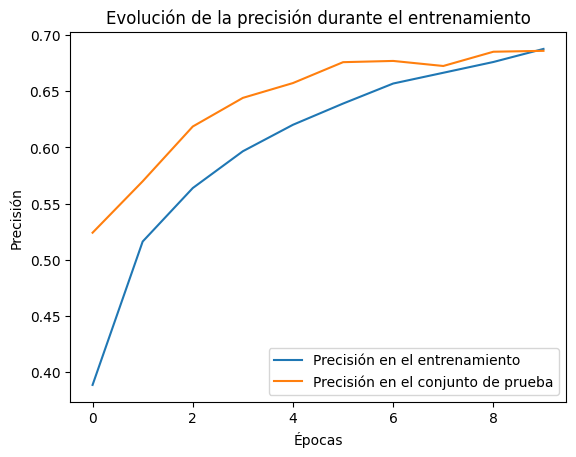

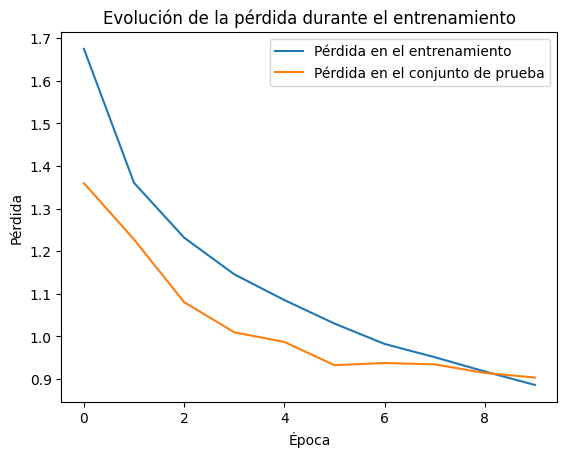

In [ ]:
import matplotlib.pyplot as plt
# Graficar la pérdida y la precisión durante el entrenamiento
plt.plot(history.history['accuracy'], label='Precisión en el entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión en el conjunto de prueba')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Evolución de la precisión durante el entrenamiento')
plt.show()

plt.plot(history.history['loss'], label='Pérdida en el entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida en el conjunto de prueba')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


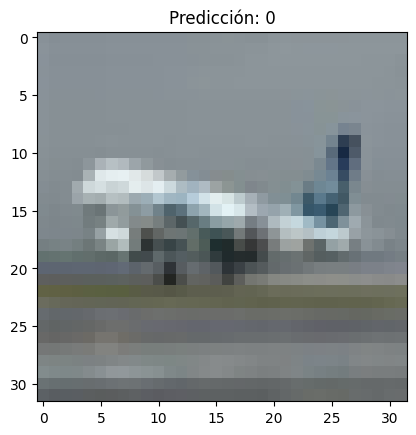

In [ ]:
# Hacer predicciones sobre el conjunto de prueba
predictions = model.predict(X_test)

# Mostrar una imagen con su predicción
import numpy as np
index = np.random.randint(0, X_test.shape[0])
plt.imshow(X_test[index])
plt.title(f"Predicción: {np.argmax(predictions[index])}")
plt.show()